# PCA (Principal Component Analysis)

## Overview
PCA is an **unsupervised dimensionality reduction** technique that transforms data into a new coordinate system where the axes (principal components) are ordered by the amount of **variance** they explain.

### Core Idea:
Find orthogonal directions (principal components) that capture maximum variance in the data.

### Algorithm:
1. **Standardize** the data (zero mean, unit variance)
2. Compute the **covariance matrix**: $\Sigma = \frac{1}{n-1} X^T X$
3. Compute **eigenvectors & eigenvalues** of $\Sigma$
4. Sort eigenvectors by eigenvalue (descending)
5. Project data: $Z = X W_k$ where $W_k$ = top $k$ eigenvectors

### Explained Variance Ratio:
$$\text{EVR}_k = \frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}$$

### Key Properties:
| Property | Detail |
|----------|--------|
| Type | Unsupervised, linear |
| Output | Orthogonal components ordered by variance |
| Scaling | Required (sensitive to feature magnitudes) |
| Info loss | Controlled by n_components |
| Use cases | Visualization, noise reduction, preprocessing |

---
### Topics Covered
1. PCA intuition — variance directions
2. Step-by-step PCA from scratch
3. Scree plot & explained variance
4. 2D & 3D visualization
5. Reconstruction & information loss
6. PCA as preprocessing for classification
7. Choosing n_components
8. PCA on image data
9. Real-world offline-safe dataset
10. PCA limitations & alternatives


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_classification, make_blobs

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
}
CLUSTER_COLORS = ['#E74C3C','#2E86AB','#27AE60','#E67E22',
                  '#9B59B6','#F39C12','#1ABC9C','#E91E63']

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. PCA Intuition — Maximum Variance Directions

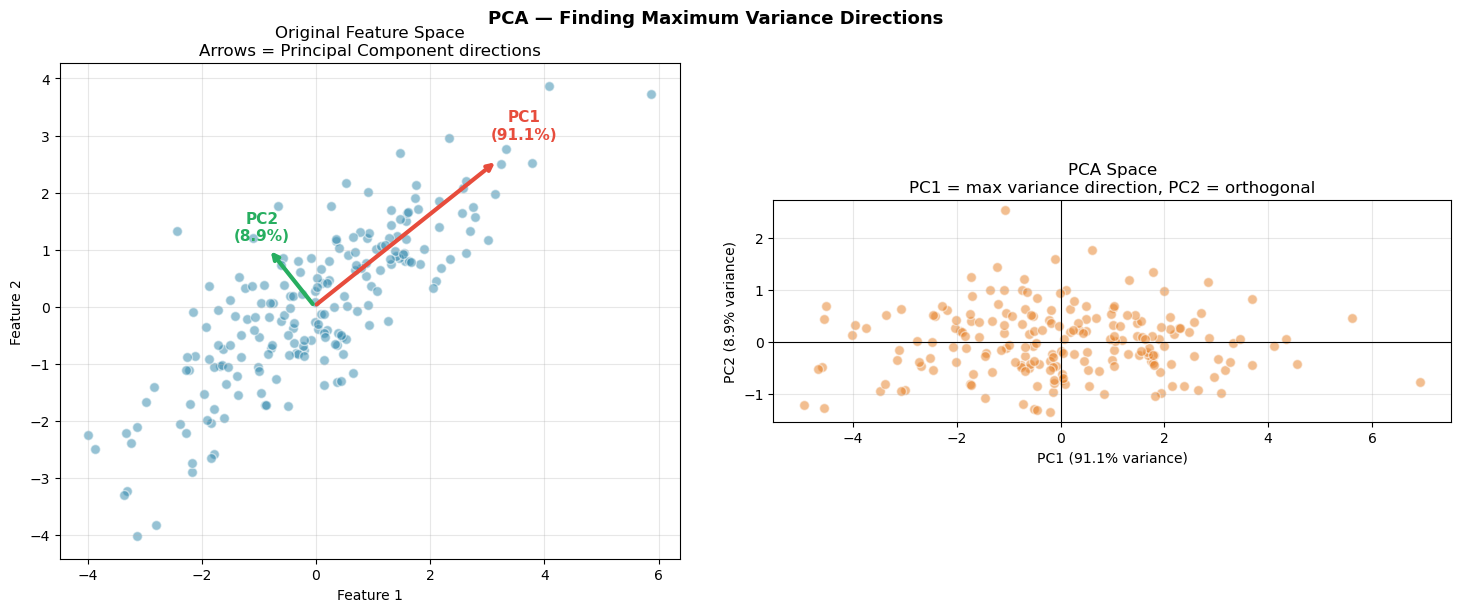

PC1 direction  : [0.7822 0.6231]
PC2 direction  : [-0.6231  0.7822]
PC1 explains   : 91.12% of variance
PC2 explains   : 8.88% of variance
PC1 · PC2      : 0.0000000000  (orthogonal = 0)


In [2]:
np.random.seed(42)
# Correlated 2D data
mean   = [0, 0]
cov    = [[3, 2], [2, 2]]
X_2d   = np.random.multivariate_normal(mean, cov, 200)

# Fit PCA
pca_2d = PCA(n_components=2)
pca_2d.fit(X_2d)
components = pca_2d.components_
explained  = pca_2d.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original space with PC arrows
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5,
                color=COLORS['primary'], edgecolors='white', s=50)
origin = np.mean(X_2d, axis=0)
scale  = [np.sqrt(pca_2d.explained_variance_[i]) * 2 for i in range(2)]
colors_pc = [COLORS['danger'], COLORS['success']]
for i in range(2):
    axes[0].annotate('', xy=origin + scale[i]*components[i],
                     xytext=origin,
                     arrowprops=dict(arrowstyle='->', color=colors_pc[i],
                                     lw=3))
    axes[0].text(*(origin + scale[i]*components[i]*1.15),
                 f'PC{i+1}\n({explained[i]*100:.1f}%)',
                 color=colors_pc[i], fontsize=11, fontweight='bold', ha='center')
axes[0].set_title('Original Feature Space\nArrows = Principal Component directions')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')
axes[0].set_aspect('equal')

# PCA space
X_pca = pca_2d.transform(X_2d)
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5,
                color=COLORS['secondary'], edgecolors='white', s=50)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('PCA Space\nPC1 = max variance direction, PC2 = orthogonal')
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[1].set_aspect('equal')

plt.suptitle('PCA — Finding Maximum Variance Directions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PC1 direction  : {components[0].round(4)}')
print(f'PC2 direction  : {components[1].round(4)}')
print(f'PC1 explains   : {explained[0]*100:.2f}% of variance')
print(f'PC2 explains   : {explained[1]*100:.2f}% of variance')
print(f'PC1 · PC2      : {np.dot(components[0], components[1]):.10f}  (orthogonal = 0)')

## 3. PCA from Scratch — Step by Step

In [3]:
np.random.seed(42)
X_scratch = np.random.multivariate_normal([0,0], [[4,2],[2,3]], 100)

# Step 1: Standardize
X_centered = X_scratch - X_scratch.mean(axis=0)

# Step 2: Covariance matrix
cov_mat = np.cov(X_centered.T)

# Step 3: Eigenvectors & eigenvalues
eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)

# Step 4: Sort descending
order      = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Step 5: Project
X_proj_scratch = X_centered @ eigenvectors[:, :1]  # keep 1 PC

# Compare with sklearn
pca_sk = PCA(n_components=1)
pca_sk.fit(X_centered)
X_proj_sk = pca_sk.transform(X_centered)

print('=== PCA from Scratch ===')
print(f'Covariance Matrix:\n{cov_mat.round(4)}')
print(f'\nEigenvalues  : {eigenvalues.round(4)}')
print(f'Eigenvectors :\n{eigenvectors.round(4)}')
print(f'\nExplained variance ratio:')
for i, (ev, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    evr = ev / eigenvalues.sum()
    print(f'  PC{i+1}: {evr*100:.2f}%  direction={vec.round(4)}')

print(f'\nScratch PC1 vs sklearn PC1 match: '
      f'{np.allclose(np.abs(X_proj_scratch.ravel()), np.abs(X_proj_sk.ravel()))}')
print('(Sign may differ — PCA eigenvectors are defined up to sign flip)')

=== PCA from Scratch ===
Covariance Matrix:
[[3.153  1.2631]
 [1.2631 2.3603]]

Eigenvalues  : [4.0804 1.4329]
Eigenvectors :
[[-0.806   0.5919]
 [-0.5919 -0.806 ]]

Explained variance ratio:
  PC1: 74.01%  direction=[-0.806  -0.5919]
  PC2: 25.99%  direction=[ 0.5919 -0.806 ]

Scratch PC1 vs sklearn PC1 match: True
(Sign may differ — PCA eigenvectors are defined up to sign flip)


## 4. Scree Plot & Cumulative Explained Variance

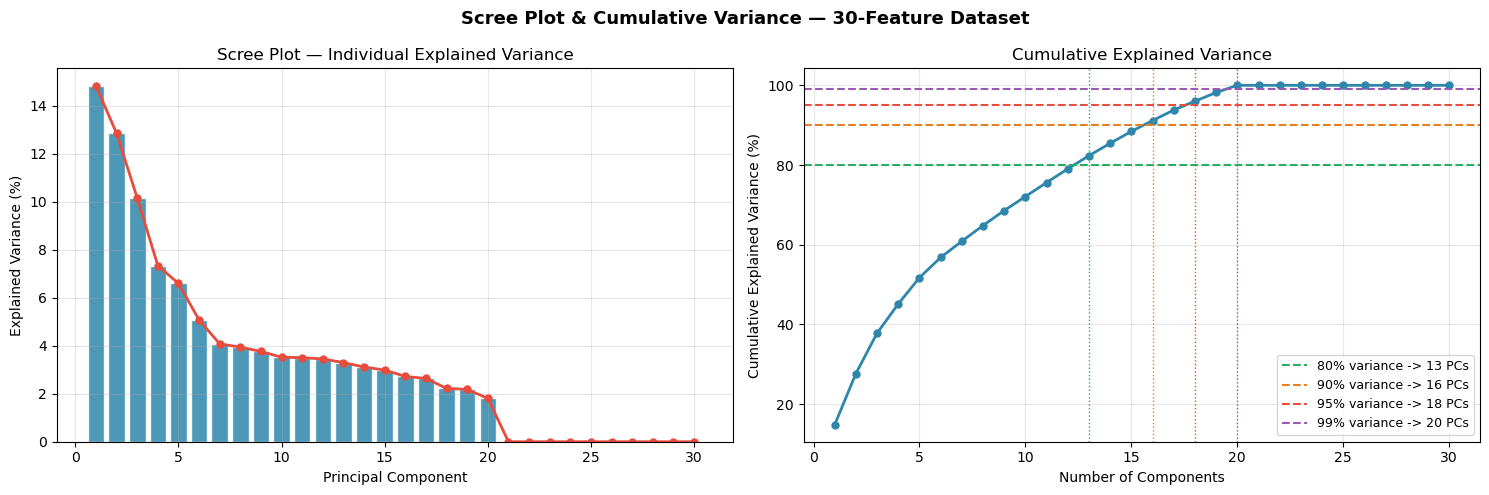

Components needed to explain variance:
  80% -> 13 components  (reduced from 30, kept 43% of features)
  90% -> 16 components  (reduced from 30, kept 53% of features)
  95% -> 18 components  (reduced from 30, kept 60% of features)
  99% -> 20 components  (reduced from 30, kept 67% of features)


In [4]:
np.random.seed(42)
X_hd, y_hd = make_classification(
    n_samples=500, n_features=30, n_informative=10,
    n_redundant=10, random_state=42
)

sc_hd   = StandardScaler()
X_hd_sc = sc_hd.fit_transform(X_hd)

pca_full = PCA()
pca_full.fit(X_hd_sc)

evr  = pca_full.explained_variance_ratio_
cumevr = np.cumsum(evr)

# Find n_components for 90%, 95%, 99%
thresholds = [0.80, 0.90, 0.95, 0.99]
n_comps    = {t: np.argmax(cumevr >= t) + 1 for t in thresholds}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
axes[0].bar(range(1, len(evr)+1), evr*100, color=COLORS['primary'],
            edgecolor='white', alpha=0.85)
axes[0].plot(range(1, len(evr)+1), evr*100, 'o-',
             color=COLORS['danger'], linewidth=2, markersize=5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Individual Explained Variance')

# Cumulative
axes[1].plot(range(1, len(cumevr)+1), cumevr*100, 'o-',
             color=COLORS['primary'], linewidth=2, markersize=5)
colors_t = [COLORS['success'], COLORS['secondary'], COLORS['danger'], COLORS['tertiary']]
for (t, nc), c in zip(n_comps.items(), colors_t):
    axes[1].axhline(t*100, color=c, linestyle='--', linewidth=1.5,
                    label=f'{int(t*100)}% variance -> {nc} PCs')
    axes[1].axvline(nc, color=c, linestyle=':', linewidth=1)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend(fontsize=9)

plt.suptitle('Scree Plot & Cumulative Variance — 30-Feature Dataset',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Components needed to explain variance:')
for t, nc in n_comps.items():
    print(f'  {int(t*100)}% -> {nc} components  '
          f'(reduced from 30, kept {nc/30*100:.0f}% of features)')

## 5. 2D & 3D Visualization of High-Dimensional Data

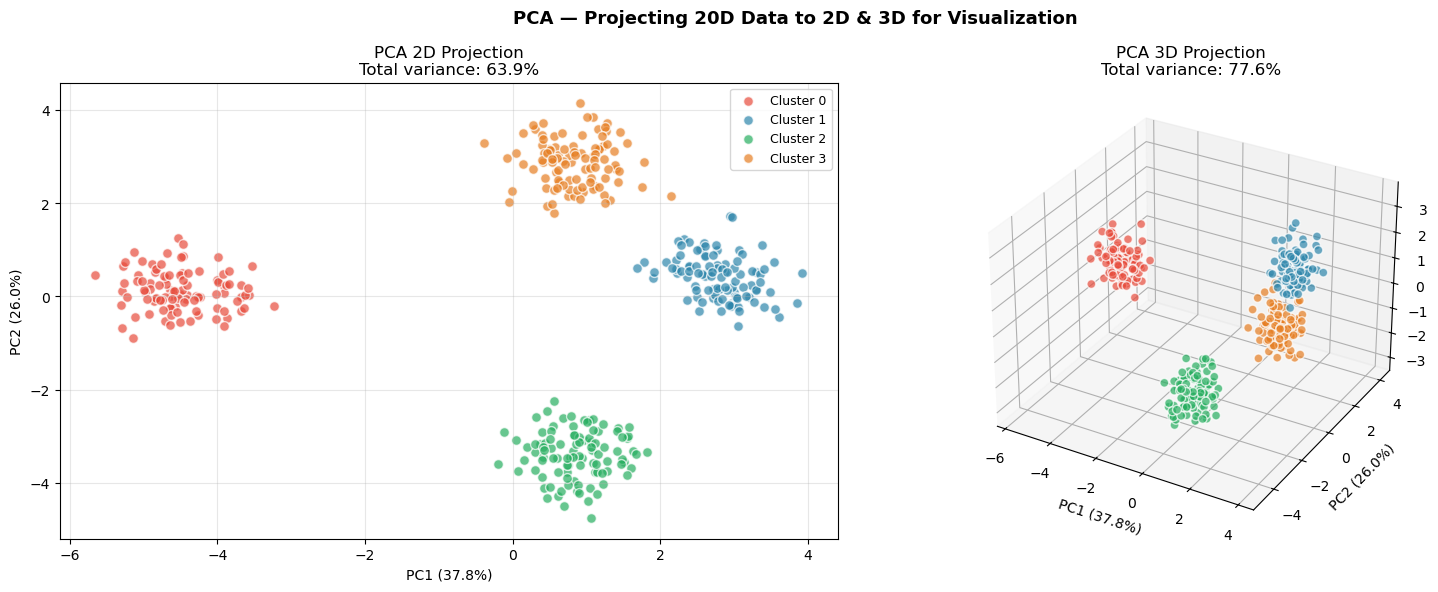

PCA allows visualization of high-dimensional data.
Original: 20 features -> Reduced: 3 components
Variance retained: 77.62%


In [5]:
np.random.seed(42)
X_vis, y_vis = make_blobs(
    n_samples=400, centers=4, n_features=20,
    cluster_std=2.5, random_state=42
)
X_vis_sc = StandardScaler().fit_transform(X_vis)

pca_3 = PCA(n_components=3)
X_vis_pca = pca_3.fit_transform(X_vis_sc)
evr_vis   = pca_3.explained_variance_ratio_

fig = plt.figure(figsize=(16, 6))

# 2D PCA
ax1 = fig.add_subplot(121)
for k in np.unique(y_vis):
    mask = y_vis == k
    ax1.scatter(X_vis_pca[mask, 0], X_vis_pca[mask, 1],
                color=CLUSTER_COLORS[k], s=50, alpha=0.7,
                edgecolors='white', label=f'Cluster {k}')
ax1.set_xlabel(f'PC1 ({evr_vis[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({evr_vis[1]*100:.1f}%)')
ax1.set_title(f'PCA 2D Projection\n'
              f'Total variance: {sum(evr_vis[:2])*100:.1f}%')
ax1.legend(fontsize=9)

# 3D PCA
ax2 = fig.add_subplot(122, projection='3d')
for k in np.unique(y_vis):
    mask = y_vis == k
    ax2.scatter(X_vis_pca[mask, 0], X_vis_pca[mask, 1], X_vis_pca[mask, 2],
                color=CLUSTER_COLORS[k], s=40, alpha=0.7, edgecolors='white')
ax2.set_xlabel(f'PC1 ({evr_vis[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({evr_vis[1]*100:.1f}%)')
ax2.set_zlabel(f'PC3 ({evr_vis[2]*100:.1f}%)')
ax2.set_title(f'PCA 3D Projection\n'
              f'Total variance: {sum(evr_vis)*100:.1f}%')

plt.suptitle('PCA — Projecting 20D Data to 2D & 3D for Visualization',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('PCA allows visualization of high-dimensional data.')
print(f'Original: 20 features -> Reduced: 3 components')
print(f'Variance retained: {sum(evr_vis)*100:.2f}%')

## 6. Reconstruction & Information Loss

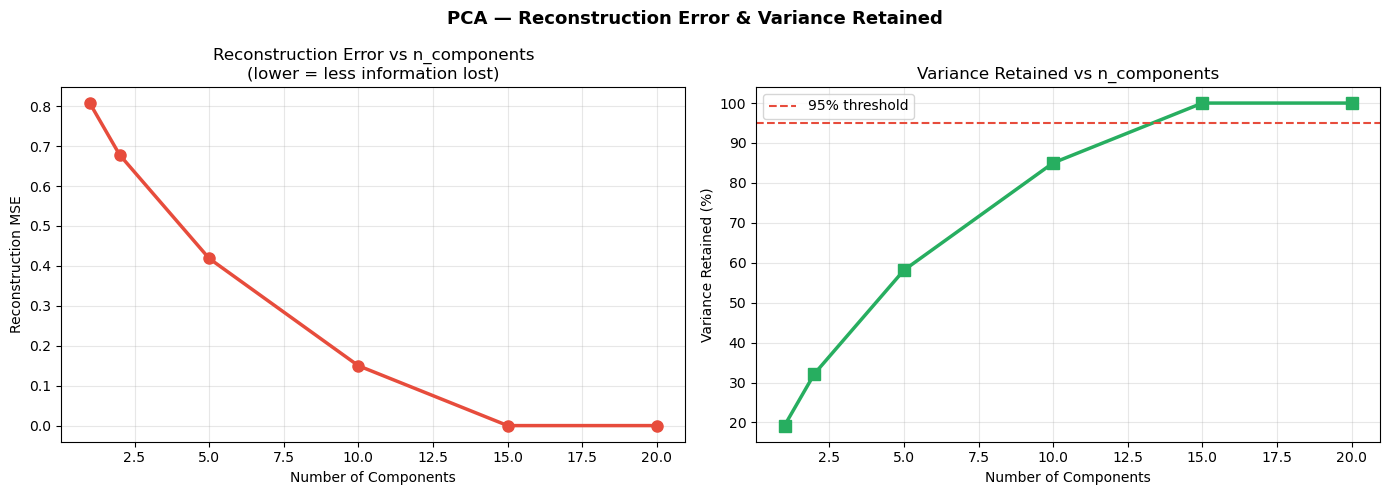

n_components | Rec MSE | Variance Retained
---------------------------------------------
           1 |  0.8078 |  19.22%
           2 |  0.6782 |  32.18%
           5 |  0.4186 |  58.14%
          10 |  0.1499 |  85.01%
          15 |  0.0000 | 100.00%
          20 |  0.0000 | 100.00%


In [6]:
np.random.seed(42)
X_rec, _ = make_classification(
    n_samples=200, n_features=20, n_informative=10,
    n_redundant=5, random_state=42
)
X_rec_sc = StandardScaler().fit_transform(X_rec)

n_comps_list = [1, 2, 5, 10, 15, 20]
rec_errors   = []
var_retained = []

for nc in n_comps_list:
    pca_r  = PCA(n_components=nc)
    X_proj = pca_r.fit_transform(X_rec_sc)
    X_back = pca_r.inverse_transform(X_proj)
    rec_errors.append(np.mean((X_rec_sc - X_back)**2))
    var_retained.append(pca_r.explained_variance_ratio_.sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_comps_list, rec_errors, 'o-', color=COLORS['danger'],
             linewidth=2.5, markersize=8)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Reconstruction MSE')
axes[0].set_title('Reconstruction Error vs n_components\n(lower = less information lost)')

axes[1].plot(n_comps_list, [v*100 for v in var_retained], 's-',
             color=COLORS['success'], linewidth=2.5, markersize=8)
axes[1].axhline(95, color=COLORS['danger'], linestyle='--',
                linewidth=1.5, label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Variance Retained (%)')
axes[1].set_title('Variance Retained vs n_components')
axes[1].legend()

plt.suptitle('PCA — Reconstruction Error & Variance Retained',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'n_components | Rec MSE | Variance Retained')
print('-' * 45)
for nc, err, var in zip(n_comps_list, rec_errors, var_retained):
    print(f'{nc:12d} | {err:7.4f} | {var*100:6.2f}%')

## 7. PCA Biplot — Components & Feature Loadings

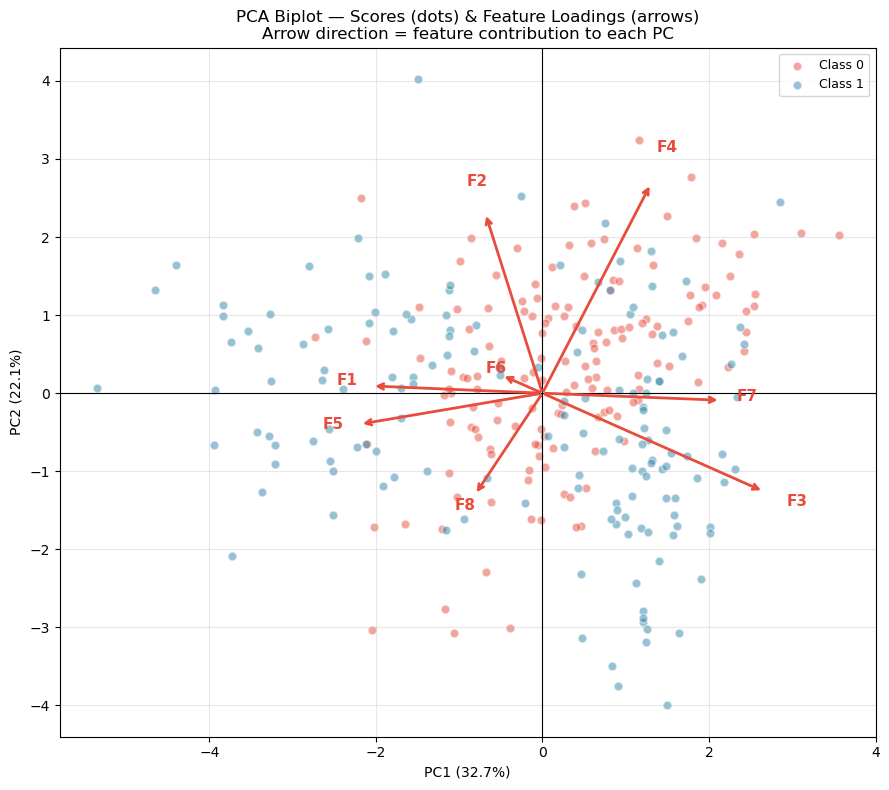

Loading interpretation:
  Long arrow    -> feature strongly influences the PC
  Parallel arrows -> features are correlated
  Opposite arrows -> features are negatively correlated

PC Loadings (component matrix):
       PC1     PC2
F1 -0.4201  0.0232
F2 -0.1410  0.5759
F3  0.5460 -0.3145
F4  0.2678  0.6706
F5 -0.4503 -0.0991
F6 -0.1004  0.0573
F7  0.4396 -0.0225
F8 -0.1665 -0.3251


In [7]:
np.random.seed(42)
n_feat = 8
X_bi, y_bi = make_classification(
    n_samples=300, n_features=n_feat, n_informative=5,
    n_redundant=2, random_state=42
)
feat_names_bi = [f'F{i+1}' for i in range(n_feat)]
X_bi_sc = StandardScaler().fit_transform(X_bi)

pca_bi  = PCA(n_components=2)
X_bi_pc = pca_bi.fit_transform(X_bi_sc)
loadings = pca_bi.components_.T * np.sqrt(pca_bi.explained_variance_)

plt.figure(figsize=(9, 8))
for k in np.unique(y_bi):
    mask = y_bi == k
    plt.scatter(X_bi_pc[mask, 0], X_bi_pc[mask, 1],
                color=CLUSTER_COLORS[k], s=40, alpha=0.5,
                edgecolors='white', label=f'Class {k}')

scale_factor = 3
for i, (load, name) in enumerate(zip(loadings, feat_names_bi)):
    plt.annotate('', xy=load*scale_factor, xytext=(0, 0),
                 arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=2))
    plt.text(load[0]*scale_factor*1.15, load[1]*scale_factor*1.15,
             name, fontsize=11, color=COLORS['danger'],
             fontweight='bold', ha='center')

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
evr_bi = pca_bi.explained_variance_ratio_
plt.xlabel(f'PC1 ({evr_bi[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({evr_bi[1]*100:.1f}%)')
plt.title('PCA Biplot — Scores (dots) & Feature Loadings (arrows)\n'
          'Arrow direction = feature contribution to each PC')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Loading interpretation:')
print('  Long arrow    -> feature strongly influences the PC')
print('  Parallel arrows -> features are correlated')
print('  Opposite arrows -> features are negatively correlated')
print()
print('PC Loadings (component matrix):')
load_df = pd.DataFrame(pca_bi.components_.T,
                        index=feat_names_bi,
                        columns=['PC1','PC2'])
print(load_df.round(4).to_string())

## 8. PCA as Preprocessing for Classification

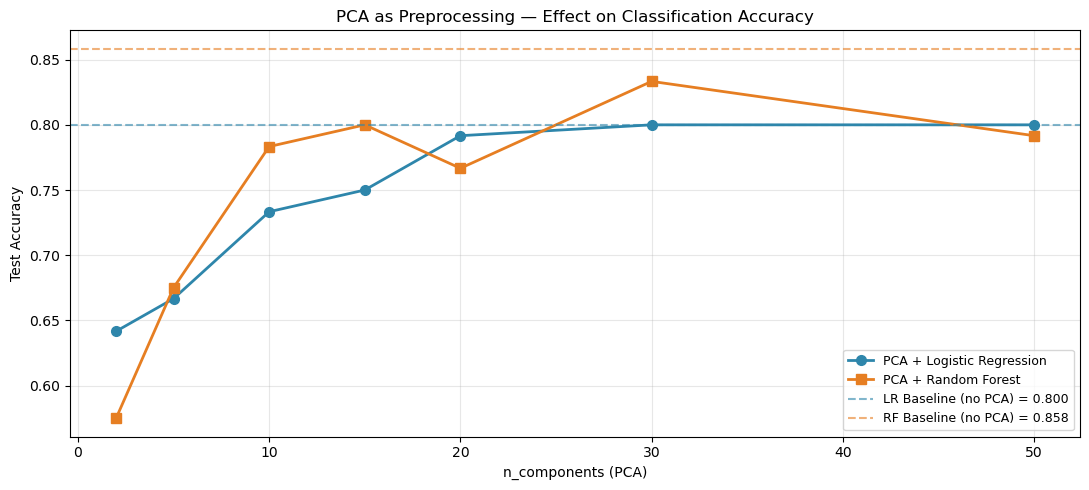

Logistic Regression best: 0.8000 at n_components=30
Random Forest best      : 0.8333 at n_components=30
LR baseline (no PCA)    : 0.8000
RF baseline (no PCA)    : 0.8583


In [8]:
np.random.seed(42)
X_cls, y_cls = make_classification(
    n_samples=600, n_features=50, n_informative=15,
    n_redundant=20, n_repeated=5, random_state=42
)
X_cls_tr, X_cls_te, y_cls_tr, y_cls_te = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

n_comps_cls = [2, 5, 10, 15, 20, 30, 50]
accs_pca_lr = []
accs_pca_rf = []

for nc in n_comps_cls:
    pipe_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=nc)),
        ('clf',    LogisticRegression(max_iter=500, random_state=42))
    ])
    pipe_rf = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=nc)),
        ('clf',    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    pipe_lr.fit(X_cls_tr, y_cls_tr)
    pipe_rf.fit(X_cls_tr, y_cls_tr)
    accs_pca_lr.append(accuracy_score(y_cls_te, pipe_lr.predict(X_cls_te)))
    accs_pca_rf.append(accuracy_score(y_cls_te, pipe_rf.predict(X_cls_te)))

# Baseline without PCA
base_lr = Pipeline([('sc', StandardScaler()),
                    ('clf', LogisticRegression(max_iter=500, random_state=42))])
base_rf = Pipeline([('sc', StandardScaler()),
                    ('clf', RandomForestClassifier(n_estimators=100,
                                                   random_state=42, n_jobs=-1))])
base_lr.fit(X_cls_tr, y_cls_tr)
base_rf.fit(X_cls_tr, y_cls_tr)
base_lr_acc = accuracy_score(y_cls_te, base_lr.predict(X_cls_te))
base_rf_acc = accuracy_score(y_cls_te, base_rf.predict(X_cls_te))

plt.figure(figsize=(11, 5))
plt.plot(n_comps_cls, accs_pca_lr, 'o-', color=COLORS['primary'],
         linewidth=2, markersize=7, label='PCA + Logistic Regression')
plt.plot(n_comps_cls, accs_pca_rf, 's-', color=COLORS['secondary'],
         linewidth=2, markersize=7, label='PCA + Random Forest')
plt.axhline(base_lr_acc, color=COLORS['primary'], linestyle='--',
            linewidth=1.5, alpha=0.6, label=f'LR Baseline (no PCA) = {base_lr_acc:.3f}')
plt.axhline(base_rf_acc, color=COLORS['secondary'], linestyle='--',
            linewidth=1.5, alpha=0.6, label=f'RF Baseline (no PCA) = {base_rf_acc:.3f}')
plt.xlabel('n_components (PCA)')
plt.ylabel('Test Accuracy')
plt.title('PCA as Preprocessing — Effect on Classification Accuracy')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

best_lr_nc = n_comps_cls[np.argmax(accs_pca_lr)]
best_rf_nc = n_comps_cls[np.argmax(accs_pca_rf)]
print(f'Logistic Regression best: {max(accs_pca_lr):.4f} at n_components={best_lr_nc}')
print(f'Random Forest best      : {max(accs_pca_rf):.4f} at n_components={best_rf_nc}')
print(f'LR baseline (no PCA)    : {base_lr_acc:.4f}')
print(f'RF baseline (no PCA)    : {base_rf_acc:.4f}')

## 9. PCA on Synthetic Image Data — Noise Reduction

ValueError: n_components=400 must be between 0 and min(n_samples, n_features)=200 with svd_solver='full'

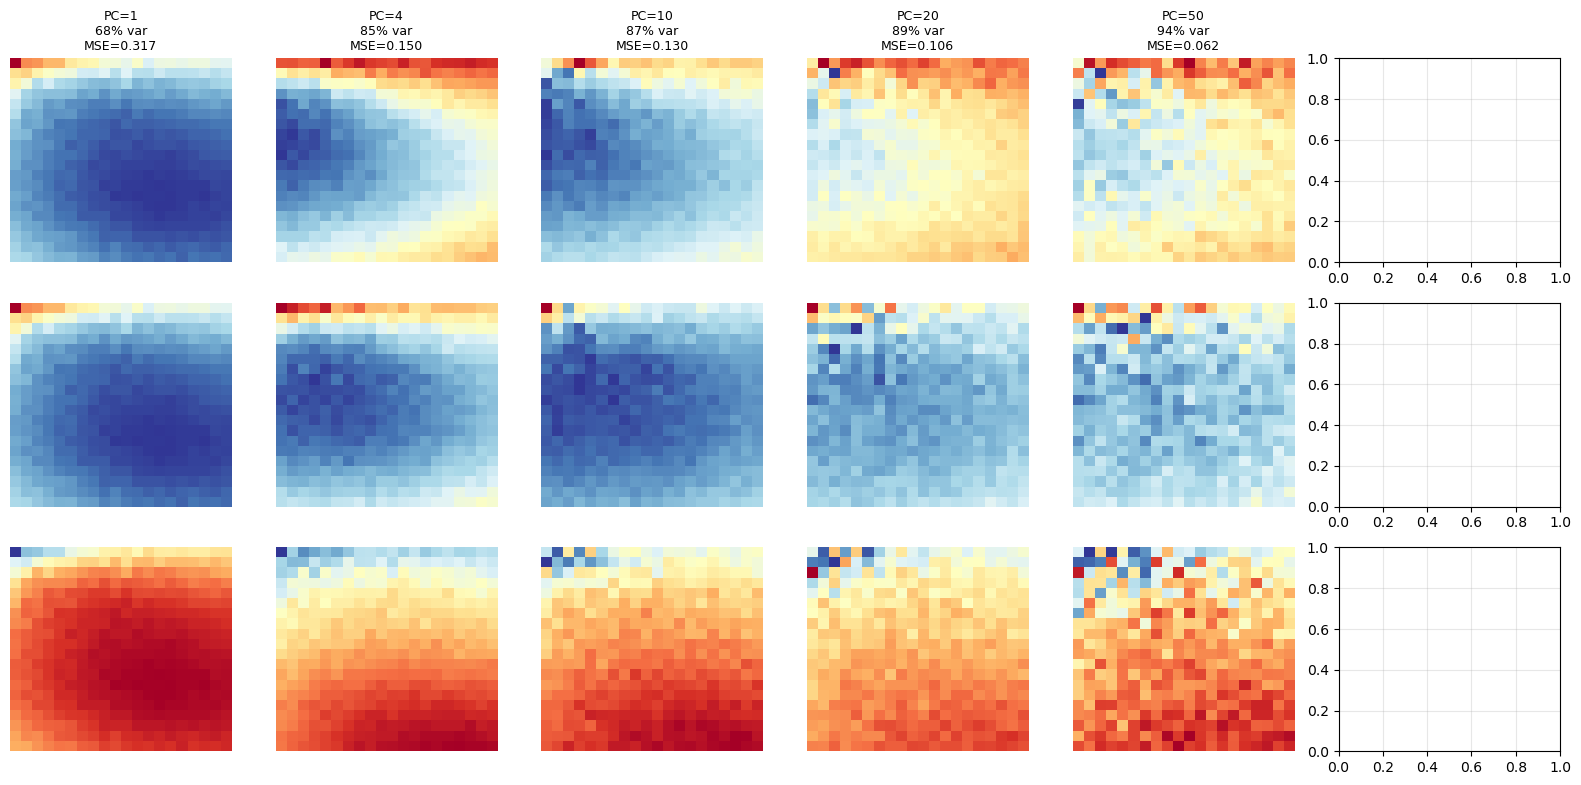

In [9]:
np.random.seed(42)
# Simulate face-like images as 20x20 pixel arrays
H, W   = 20, 20
n_imgs = 200

# Underlying signal: simple gradient patterns
base_patterns = [
    np.outer(np.linspace(0,1,H), np.ones(W)),
    np.outer(np.ones(H), np.linspace(0,1,W)),
    np.outer(np.linspace(0,1,H), np.linspace(1,0,W)),
    np.sin(np.outer(np.linspace(0, np.pi, H), np.ones(W))),
]
weights = np.random.randn(n_imgs, 4) * [2, 1.5, 1, 0.8]
images  = sum(w[:, None, None] * p for w, p in
              zip(weights.T, base_patterns))
images += np.random.randn(n_imgs, H, W) * 0.5   # add noise

X_img    = images.reshape(n_imgs, H*W)
X_img_sc = StandardScaler().fit_transform(X_img)

n_comps_img_list = [1, 4, 10, 20, 50, H*W]
n_comps_img_list = [nc for nc in n_comps_img_list if nc <= H*W]

fig, axes = plt.subplots(3, len(n_comps_img_list), figsize=(20, 9))

# Pick 3 sample images
sample_idxs = [0, 50, 100]

for col, nc in enumerate(n_comps_img_list):
    pca_img = PCA(n_components=nc)
    X_proj  = pca_img.fit_transform(X_img_sc)
    X_rec   = pca_img.inverse_transform(X_proj)
    evr_img = pca_img.explained_variance_ratio_.sum()
    mse_img = np.mean((X_img_sc - X_rec)**2)

    for row, idx in enumerate(sample_idxs):
        axes[row][col].imshow(
            X_rec[idx].reshape(H, W), cmap='RdYlBu', aspect='auto'
        )
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(
                f'PC={nc}\n{evr_img*100:.0f}% var\nMSE={mse_img:.3f}',
                fontsize=9
            )

for row, idx in enumerate(sample_idxs):
    axes[row][0].set_ylabel(f'Sample {idx}', fontsize=9)

plt.suptitle('PCA Image Reconstruction — More PCs = Less Noise, More Detail',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Real-World Offline-Safe Dataset — Patient Lab Results

Lab dataset shape : (500, 15)
Class balance     : [299 201]


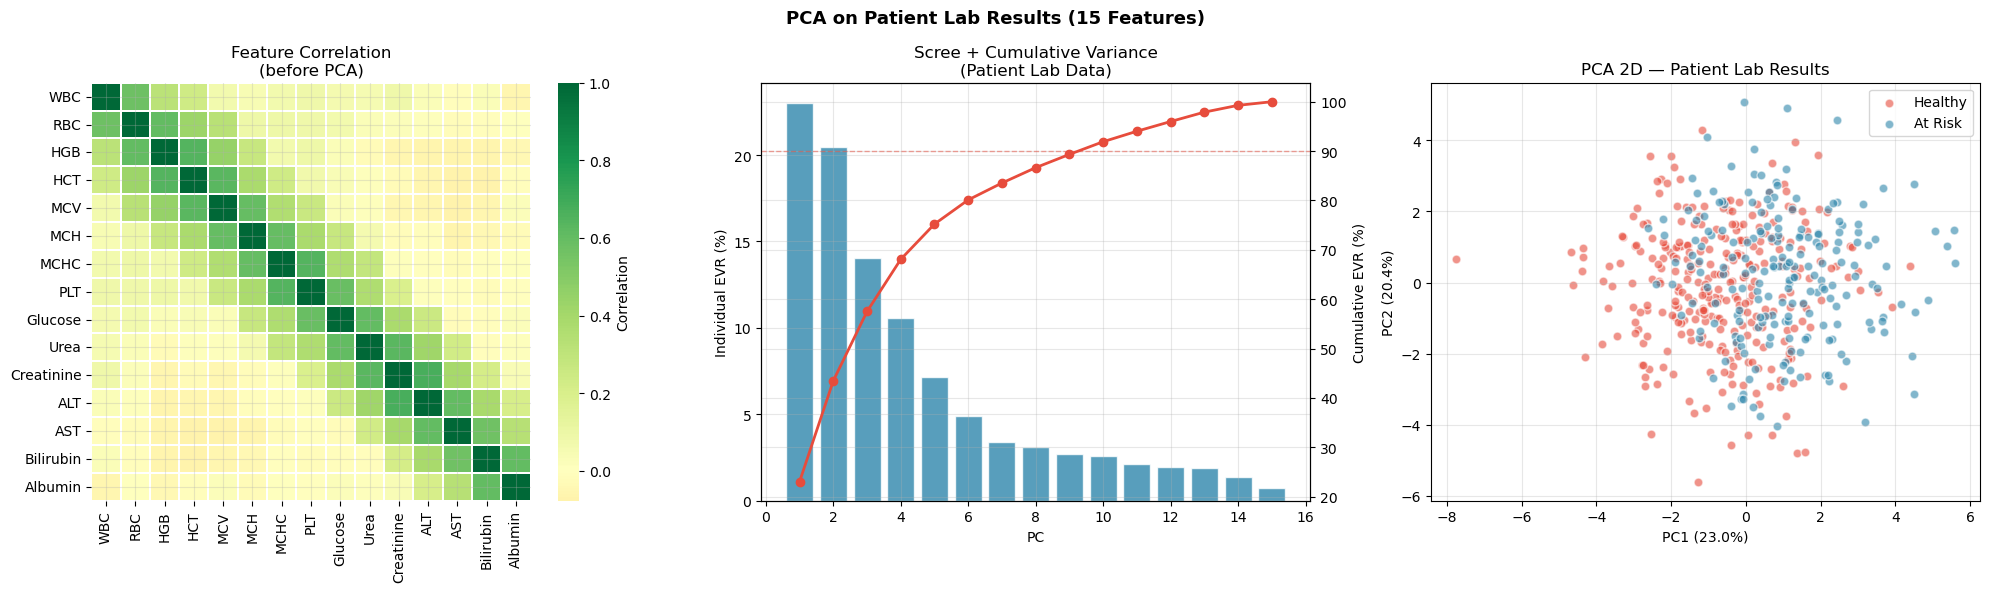

Original features : 15
PCs for 90% var   : 10
Dimensionality reduction: 15 -> 10 (33% reduction)


In [10]:
np.random.seed(42)
n_pat = 500

# 15 correlated lab features
cov_base = np.eye(15) * 1.0
for i in range(15):
    for j in range(15):
        if abs(i-j) <= 3:
            cov_base[i, j] = 0.6 ** abs(i-j)

X_lab = np.random.multivariate_normal(np.zeros(15), cov_base, n_pat)
feat_names_lab = ['WBC','RBC','HGB','HCT','MCV','MCH','MCHC',
                  'PLT','Glucose','Urea','Creatinine','ALT',
                  'AST','Bilirubin','Albumin']

# Binary outcome: high WBC + high Glucose -> at risk
y_lab = ((X_lab[:, 0] + X_lab[:, 8] + np.random.randn(n_pat)*0.5) > 0.5).astype(int)

print(f'Lab dataset shape : {X_lab.shape}')
print(f'Class balance     : {np.bincount(y_lab)}')

X_lab_sc = StandardScaler().fit_transform(X_lab)

# Full PCA
pca_lab = PCA()
pca_lab.fit(X_lab_sc)

# Correlation heatmap before PCA
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.heatmap(pd.DataFrame(X_lab_sc, columns=feat_names_lab).corr(),
            cmap='RdYlGn', center=0, annot=False,
            linewidths=0.3, ax=axes[0],
            cbar_kws={'label': 'Correlation'})
axes[0].set_title('Feature Correlation\n(before PCA)')

# Scree
evr_lab  = pca_lab.explained_variance_ratio_
cumevr_l = np.cumsum(evr_lab)
axes[1].bar(range(1, 16), evr_lab*100, color=COLORS['primary'],
            edgecolor='white', alpha=0.8)
ax1b = axes[1].twinx()
ax1b.plot(range(1, 16), cumevr_l*100, 'o-',
          color=COLORS['danger'], linewidth=2, markersize=6)
ax1b.axhline(90, color=COLORS['danger'], linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('PC'); axes[1].set_ylabel('Individual EVR (%)')
ax1b.set_ylabel('Cumulative EVR (%)')
axes[1].set_title('Scree + Cumulative Variance\n(Patient Lab Data)')

# 2D PCA scatter
X_lab_2d = PCA(n_components=2).fit_transform(X_lab_sc)
for k in [0, 1]:
    mask = y_lab == k
    axes[2].scatter(X_lab_2d[mask, 0], X_lab_2d[mask, 1],
                    color=CLUSTER_COLORS[k], s=40, alpha=0.6,
                    edgecolors='white',
                    label='At Risk' if k else 'Healthy')
axes[2].set_xlabel(f'PC1 ({evr_lab[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({evr_lab[1]*100:.1f}%)')
axes[2].set_title('PCA 2D — Patient Lab Results')
axes[2].legend()

plt.suptitle('PCA on Patient Lab Results (15 Features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

nc_90 = np.argmax(cumevr_l >= 0.90) + 1
print(f'Original features : 15')
print(f'PCs for 90% var   : {nc_90}')
print(f'Dimensionality reduction: {15} -> {nc_90} ({(1-nc_90/15)*100:.0f}% reduction)')

## 11. PCA Limitations & Alternatives

In [11]:
from sklearn.manifold import TSNE

np.random.seed(42)
# Dataset where PCA fails — non-linear structure
from sklearn.datasets import make_swiss_roll
X_sw, color_sw = make_swiss_roll(n_samples=800, noise=0.1, random_state=42)
X_sw_sc = StandardScaler().fit_transform(X_sw)

# PCA projection
X_sw_pca = PCA(n_components=2).fit_transform(X_sw_sc)

# t-SNE projection
X_sw_tsne = TSNE(n_components=2, perplexity=30,
                 random_state=42, n_iter=500).fit_transform(X_sw_sc)

fig = plt.figure(figsize=(18, 5))

# 3D original
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X_sw[:, 0], X_sw[:, 1], X_sw[:, 2],
            c=color_sw, cmap='Spectral', s=20, alpha=0.7)
ax1.set_title('Swiss Roll (3D original)\nNon-linear manifold')

# PCA 2D
ax2 = fig.add_subplot(132)
sc2 = ax2.scatter(X_sw_pca[:, 0], X_sw_pca[:, 1],
                  c=color_sw, cmap='Spectral', s=20, alpha=0.7)
ax2.set_title('PCA Projection (2D)\nLinear -> rolls collapse, structure lost')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2')

# t-SNE 2D
ax3 = fig.add_subplot(133)
ax3.scatter(X_sw_tsne[:, 0], X_sw_tsne[:, 1],
            c=color_sw, cmap='Spectral', s=20, alpha=0.7)
ax3.set_title('t-SNE Projection (2D)\nNon-linear -> manifold unrolled')
ax3.set_xlabel('tSNE-1'); ax3.set_ylabel('tSNE-2')

plt.suptitle('PCA vs t-SNE — Linear vs Non-Linear Dimensionality Reduction',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('PCA   : linear, fast, interpretable, good for correlated features')
print('t-SNE : non-linear, great for visualization, slow, not for preprocessing')
print()
print('Other alternatives:')
print('  UMAP       : faster than t-SNE, better global structure preservation')
print('  Kernel PCA : non-linear PCA using kernel trick')
print('  ICA        : finds statistically independent (not orthogonal) components')
print('  NMF        : non-negative factorization, good for text/images')

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## 12. Final Summary & Key Takeaways

In [12]:
print('=' * 68)
print('                  PCA - KEY TAKEAWAYS')
print('=' * 68)

takeaways = [
    ('Core idea',         'Project to directions of maximum variance (eigenvectors)'),
    ('Components',        'Orthogonal, ordered by explained variance (largest first)'),
    ('Scaling',           'ALWAYS StandardScaler before PCA — sensitive to scale'),
    ('Scree plot',        'Bar chart of individual EVR; look for elbow to choose K'),
    ('Cumulative EVR',    'Choose n_components where cumulative EVR >= 90% or 95%'),
    ('Biplot',            'Scores + loading arrows; shows feature contributions to PCs'),
    ('Reconstruction',    'inverse_transform() recovers original space (with loss)'),
    ('Classification',    'PCA can help LR more than RF (LR benefits from decorrelation)'),
    ('Noise reduction',   'Low PCs capture signal; high PCs capture noise'),
    ('Interpretability',  'PCs are linear combos of features — harder to interpret'),
    ('Limitation',        'Linear only; fails to unroll non-linear manifolds'),
    ('vs t-SNE',          'PCA: preprocessing + fast; t-SNE: visualization only + slow'),
    ('vs UMAP',           'UMAP: faster than t-SNE, better for large data'),
    ('Unsupervised',      'PCA ignores labels — use LDA if labels are available'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<22}  ->  {detail}')

print('=' * 68)

                  PCA - KEY TAKEAWAYS
  OK  Core idea               ->  Project to directions of maximum variance (eigenvectors)
  OK  Components              ->  Orthogonal, ordered by explained variance (largest first)
  OK  Scaling                 ->  ALWAYS StandardScaler before PCA — sensitive to scale
  OK  Scree plot              ->  Bar chart of individual EVR; look for elbow to choose K
  OK  Cumulative EVR          ->  Choose n_components where cumulative EVR >= 90% or 95%
  OK  Biplot                  ->  Scores + loading arrows; shows feature contributions to PCs
  OK  Reconstruction          ->  inverse_transform() recovers original space (with loss)
  OK  Classification          ->  PCA can help LR more than RF (LR benefits from decorrelation)
  OK  Noise reduction         ->  Low PCs capture signal; high PCs capture noise
  OK  Interpretability        ->  PCs are linear combos of features — harder to interpret
  OK  Limitation              ->  Linear only; fails to unrol

---
## Practice Exercises

1. **Implement PCA from scratch** using only NumPy eigen decomposition and verify it matches sklearn.
2. **Compare PCA vs LDA** on a labelled dataset — which gives better class separation in 2D?
3. **Try n_components='mle'** — sklearn can auto-select n_components using Minka's MLE.
4. **Apply Kernel PCA** (`sklearn.decomposition.KernelPCA`) on the swiss roll and compare with linear PCA.
5. **Build a full pipeline** — StandardScaler + PCA + GridSearchCV to tune n_components jointly with classifier.
6. **Plot the covariance matrix before and after PCA** — verify PCA produces a diagonal covariance.

---
*Notebook created for the ML Repository — PCA module.*